In [1]:
import asyncio
from collections import defaultdict
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [2]:
import sys
from pathlib import Path

# Asumiendo que notebooks/ está dentro de la raíz del proyecto
root_path = Path().resolve().parent  # sube un nivel
sys.path.append(str(root_path))

In [3]:
from agents.classifier_agent import ClassifierAgent
from agents.aggregator_agent import AggregatorAgent
from data.dataset_registry import DatasetRegistry
from data.loaders.sklearn_loader import SklearnLoader

In [4]:
import asyncio
import numpy as np
import torch

from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

from data.dataset_registry import DatasetRegistry
from data.loaders.sklearn_loader import SklearnLoader

from agents.classifier_agent import ClassifierAgent
from agents.aggregator_agent import AggregatorAgent

from explainers.shap_explainer import ShapExplainer

from models.sklearn_model import SklearnModel
from models.torch_model import TorchModel
from models.random_forest import RandomForest as AdvancedRF

# Visualización (todo en un solo módulo como acordamos)
from visualization.visualization import (
    plot_metrics_over_time,
    plot_explanation_similarity,
    plot_explanation_divergence,
    plot_agents_dashboard
)

from visualization.logs import log

import torch.nn as nn
from models.torch_model import TorchModel

class IrisMLP(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=16, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)



async def run_test():
    print("\n==================== TEST MULTI-AGENT ====================")

    # ------------------- Dataset -------------------
    registry = DatasetRegistry()
    dataset_id = "iris"
    registry.register(dataset_id, SklearnLoader(load_iris))

    X, y, meta = registry.load(dataset_id)
    print(f"[Dataset] {dataset_id} cargado → X={X.shape}, y={y.shape}")

    instance = X[:1]

    # ------------------- Modelos -------------------
    rf_base = SklearnModel(
        RandomForestClassifier(n_estimators=20, random_state=0)
    )

    rf_adv = AdvancedRF(
        n_estimators=30,
        max_depth=5,
        random_state=1
    )

    torch_model = TorchModel(
        nn_model=IrisMLP(input_dim=X.shape[1]),
        lr=1e-3,
        epochs=5,
        batch_size=16
    )

    # ------------------- Clasificadores -------------------
    classifiers = {
        "rf_base": ClassifierAgent(
            agent_id="rf_base",
            model=rf_base,
            explainers=[ShapExplainer()],
            dataset_id=dataset_id,
            registry=registry
        ),
        "rf_adv": ClassifierAgent(
            agent_id="rf_adv",
            model=rf_adv,
            explainers=[ShapExplainer()],
            dataset_id=dataset_id,
            registry=registry
        ),
        "nn_torch": ClassifierAgent(
            agent_id="nn_torch",
            model=torch_model,
            explainers=[ShapExplainer()],  # luego puedes cambiar por DeepSHAP
            dataset_id=dataset_id,
            registry=registry
        )
    }

    classifier_ids = list(classifiers.keys())

    # ------------------- Aggregator -------------------
    aggregator = AggregatorAgent(
        classifier_ids=classifier_ids,
        max_iterations=2,   # 🔴 solo 2 iteraciones para depuración
        alpha=0.4,
        beta=0.15,
        gamma=0.25
    )

    # ------------------- Queues -------------------
    queues = {cid: agent.inbox for cid, agent in classifiers.items()}
    queues["aggregator"] = aggregator.inbox

    # ------------------- Setup -------------------
    print("\n[Setup] Inicializando agentes...\n")
    await asyncio.gather(*(agent.setup() for agent in classifiers.values()))
    log("Inicializando AggregatorAgent")

    # ------------------- Tasks -------------------
    tasks = [
        asyncio.create_task(agent.run(queues))
        for agent in classifiers.values()
    ]
    tasks.append(
        asyncio.create_task(
            aggregator.run(queues, instance)
        )
    )

    await asyncio.gather(*tasks)

    print("\n==================== TEST FINALIZADO ✅ ====================\n")

    # =========================================================
    # VISUALIZACIÓN
    # =========================================================

    print("\n[Visualización] Métricas por agente\n")

    for agent in classifiers.values():
        plot_metrics_over_time(agent.metrics_history, metric_name="accuracy")
        plot_metrics_over_time(agent.metrics_history, metric_name="f1")

        plot_explanation_similarity(agent)

    print("\n[Visualización] Divergencia global de explicaciones\n")
    plot_explanation_divergence(classifiers)

    print("\n[Visualización] Dashboard global\n")
    plot_agents_dashboard(classifiers)



==================== TEST MULTI-AGENT ====================
[Dataset] iris cargado → X=(150, 4), y=(150,)

[Setup] Inicializando agentes...

[rf_base] Setup iniciado
[rf_base] 19:30:17 | Setup iniciado (train + eval inicial)
[rf_base] 19:30:17 | Entrenando modelo (iter=0, initial=True)
[rf_base] 19:30:17 | Evaluación completada | acc=0.933
[rf_base] 19:30:17 | Setup completado
[rf_adv] Setup iniciado
[rf_adv] 19:30:17 | Setup iniciado (train + eval inicial)
[rf_adv] 19:30:17 | Entrenando modelo (iter=0, initial=True)
[rf_adv] 19:30:17 | Evaluación completada | acc=0.900
[rf_adv] 19:30:17 | Setup completado
[nn_torch] Setup iniciado
[nn_torch] 19:30:17 | Setup iniciado (train + eval inicial)
[nn_torch] 19:30:17 | Entrenando modelo (iter=0, initial=True)
[nn_torch] 19:30:17 | Evaluación completada | acc=0.733
[nn_torch] 19:30:17 | Setup completado
[SYSTEM] 19:30:17 | Inicializando AggregatorAgent
[Aggregator] Inicio

[Aggregator] Iteración 0
[rf_base] 19:30:17 | Clasificando instancia


c:\Users\saulr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[rf_base] 19:30:22 | Calculando explicaciones
[rf_base] 19:30:22 | Clasificación completada
[rf_adv] 19:30:22 | Clasificando instancia
[rf_adv] 19:30:22 | Calculando explicaciones
[rf_adv] 19:30:22 | Clasificación completada
[nn_torch] 19:30:22 | Clasificando instancia
[nn_torch] 19:30:23 | Calculando explicaciones
[nn_torch] 19:30:23 | Clasificación completada
[AGGREGATOR] 19:30:23 | Recibidas 3 respuestas
[Aggregator] Majority = 0
[Aggregator] Scores = [1.0290423532534159, 1.003244076378619, 0.5657089729033307]
[Aggregator] Decisions = ['keep', 'soft_adjust', 'adjust']
[AGGREGATOR] 19:30:23 | Calculando feedback global
[AGGREGATOR] 19:30:23 | Iteración 0 completada

[Aggregator] Iteración 1
[rf_base] 19:30:23 | Ajustando modelo | iter=0 | strategy=keep
[rf_base] 19:30:23 | Entrenando modelo (iter=0, initial=False)
[rf_base] 19:30:23 | Evaluación completada | acc=0.933
[rf_base] Iter 0 | Estrategia=keep | F1=0.933
[rf_base] 19:30:23 | Clasificando instancia
[rf_base] 19:30:23 | Calcul

c:\Users\saulr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


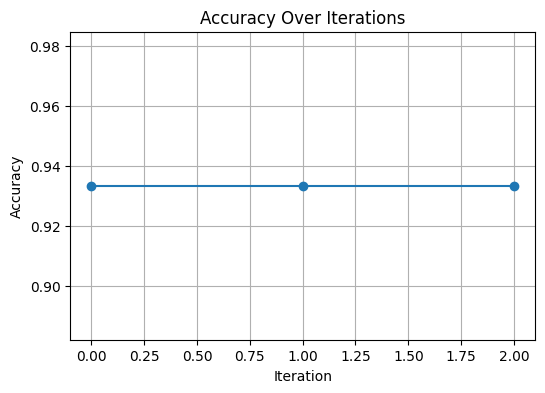

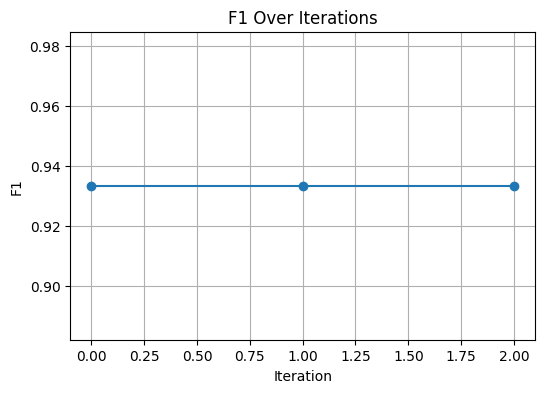

[rf_base] No hay suficiente histórico de explicaciones


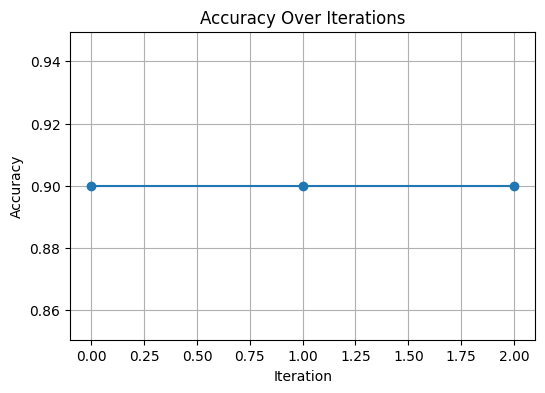

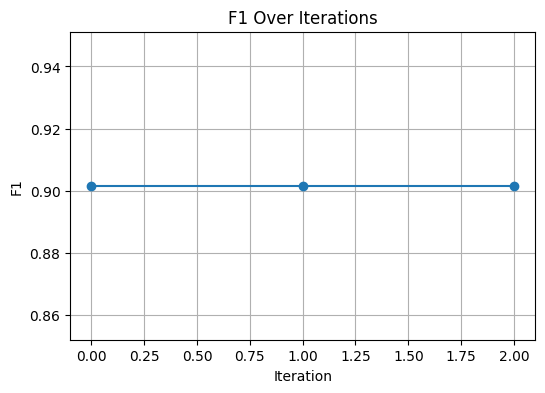

[rf_adv] No hay suficiente histórico de explicaciones


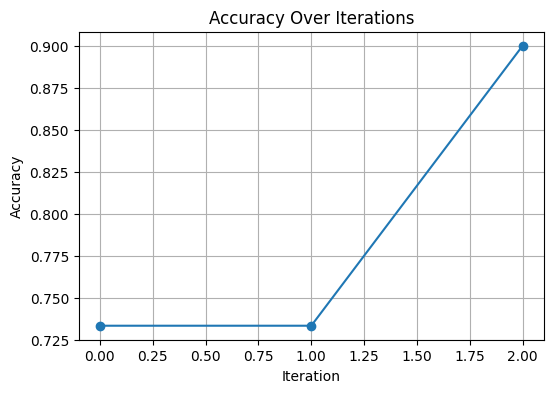

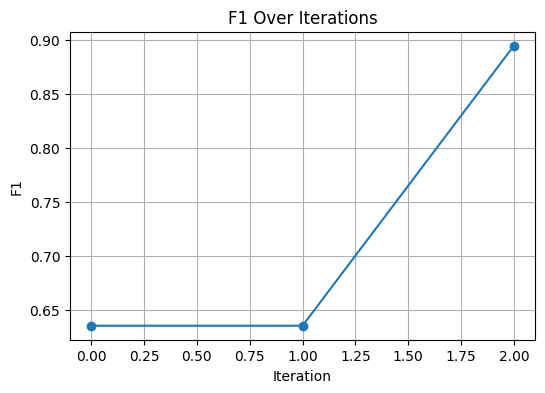

[nn_torch] No hay suficiente histórico de explicaciones

[Visualización] Divergencia global de explicaciones



AttributeError: 'ClassifierAgent' object has no attribute 'explanation_history'

In [5]:
await run_test()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# 1. EVOLUCIÓN DE MÉTRICAS POR AGENTE
# ============================================================

def metrics_table(agents):
    rows = []
    for agent_id, agent in agents.items():
        for m in agent.metrics_history:
            row = {"agent": agent_id}
            row.update(m)
            rows.append(row)

    df = pd.DataFrame(rows)
    return df.sort_values(["agent", "iteration"])


# ============================================================
# 2. ESTABILIDAD DE EXPLICACIONES (INTRA-AGENTE)
#    Similaridad coseno entre iteraciones consecutivas
# ============================================================

def explanation_stability(agents):
    rows = []

    for agent_id, agent in agents.items():
        hist = getattr(agent, "explanation_history", [])

        if len(hist) < 2:
            continue

        sims = []
        for i in range(1, len(hist)):
            s = cosine_similarity(
                hist[i - 1].reshape(1, -1),
                hist[i].reshape(1, -1)
            )[0, 0]
            sims.append(s)

        rows.append({
            "agent": agent_id,
            "iterations": len(hist),
            "mean_similarity": float(np.mean(sims)),
            "min_similarity": float(np.min(sims)),
            "max_similarity": float(np.max(sims)),
            "std_similarity": float(np.std(sims))
        })

    return pd.DataFrame(rows)


# ============================================================
# 3. CONVERGENCIA GLOBAL ENTRE AGENTES (INTER-AGENTE)
#    Similaridad media respecto al vector explicativo medio
# ============================================================

def global_explanation_convergence(agents):
    agents = {
        k: a for k, a in agents.items()
        if hasattr(a, "explanation_history") and len(a.explanation_history) > 0
    }

    min_len = min(len(a.explanation_history) for a in agents.values())
    rows = []

    for t in range(min_len):
        vectors = np.array([
            a.explanation_history[t] for a in agents.values()
        ])

        mean_vec = vectors.mean(axis=0)

        sims = [
            cosine_similarity(
                v.reshape(1, -1),
                mean_vec.reshape(1, -1)
            )[0, 0]
            for v in vectors
        ]

        rows.append({
            "iteration": t,
            "mean_similarity": float(np.mean(sims)),
            "min_similarity": float(np.min(sims)),
            "max_similarity": float(np.max(sims)),
            "std_similarity": float(np.std(sims))
        })

    return pd.DataFrame(rows)


# ============================================================
# 4. EJECUCIÓN Y SALIDA
# ============================================================

print("\n================ MÉTRICAS POR AGENTE ================\n")
df_metrics = metrics_table(classifiers)
display(df_metrics)

print("\n================ ESTABILIDAD DE EXPLICACIONES ================\n")
df_stability = explanation_stability(classifiers)
display(df_stability)

print("\n================ CONVERGENCIA GLOBAL DE EXPLICACIONES ================\n")
df_convergence = global_explanation_convergence(classifiers)
display(df_convergence)